# **LOGISTIC REGRESSION HAND'S ON PRACTICAL:**

## Classification techniques are an essential part of machine learning and data mining applications. Approximately 70% of problems in Data Science are classification problems. There are lots of classification problems that are available, but the logistics regression is common and is a useful regression method for solving the binary classification problem. Another category of classification is Multinomial classification, which handles the issues where multiple classes are present in the target variable. For example, IRIS dataset a very famous example of multi-class classification. Other examples are classifying article/blog/document category.

# **Logistic Regression can be used for various classification problems such as spam detection. Diabetes prediction, if a given customer will purchase a particular product or will they churn another competitor, whether the user will click on a given advertisement link or not, and many more examples are in the bucket.**

# **Logistic Regression is one of the most simple and commonly used Machine Learning algorithms for two-class classification. It is easy to implement and can be used as the baseline for any binary classification problem. Its basic fundamental concepts are also constructive in deep learning. Logistic regression describes and estimates the relationship between one dependent binary variable and independent variables.**

# **In this lecture, you will learn the following things in Logistic Regression:**

    Introduction to Logistic Regression
    Linear Regression Vs. Logistic Regression
    Maximum Likelihood Estimation Vs. Ordinary Least Square Method
    How do Logistic Regression works?
    Model building in Scikit-learn
    Model Evaluation using Confusion Matrix.
    Advantages and Disadvantages of Logistic Regression


# **Logistic Regression**

Logistic regression is a statistical method for predicting binary classes. The outcome or target variable is dichotomous in nature. Dichotomous means there are only two possible classes. For example, it can be used for cancer detection problems. It computes the probability of an event occurrence.

It is a special case of linear regression where the target variable is categorical in nature. It uses a log of odds as the dependent variable. Logistic Regression predicts the probability of occurrence of a binary event utilizing a logit function.

# **Linear Regression Equation:**

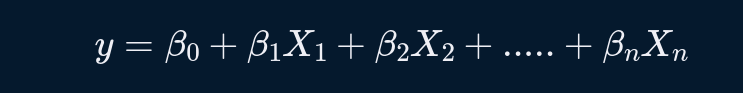


Where, y is dependent variable and x1, x2 ... and Xn are explanatory variables.

Sigmoid Function:

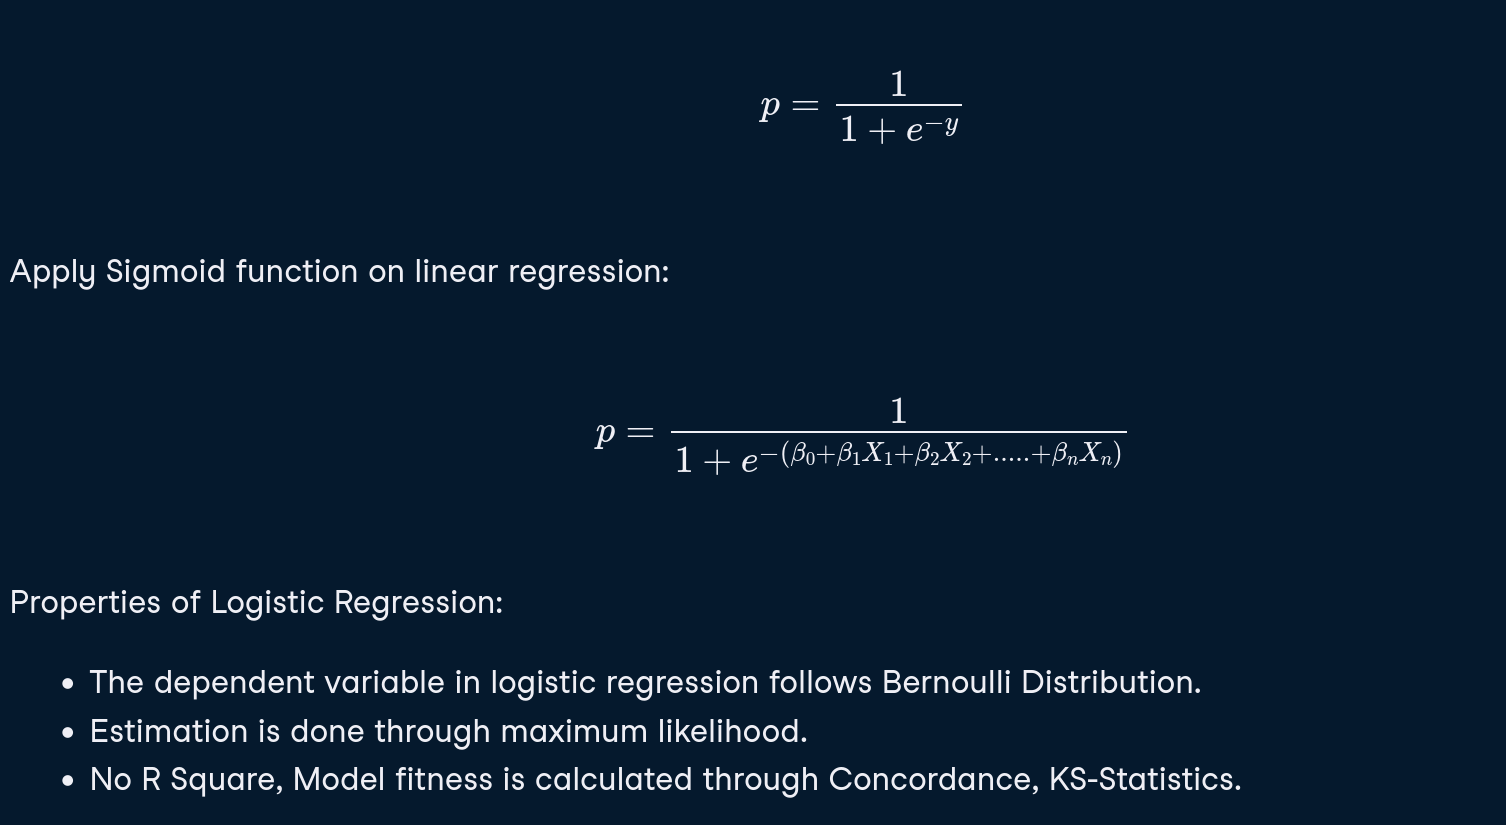

# **Linear Regression Vs. Logistic Regression**

Linear regression gives you a continuous output, but logistic regression provides a constant output. An example of the continuous output is house price and stock price. Example's of the discrete output is predicting whether a patient has cancer or not, predicting whether the customer will churn. Linear regression is estimated using Ordinary Least Squares (OLS) while logistic regression is estimated using Maximum Likelihood Estimation (MLE) approach.

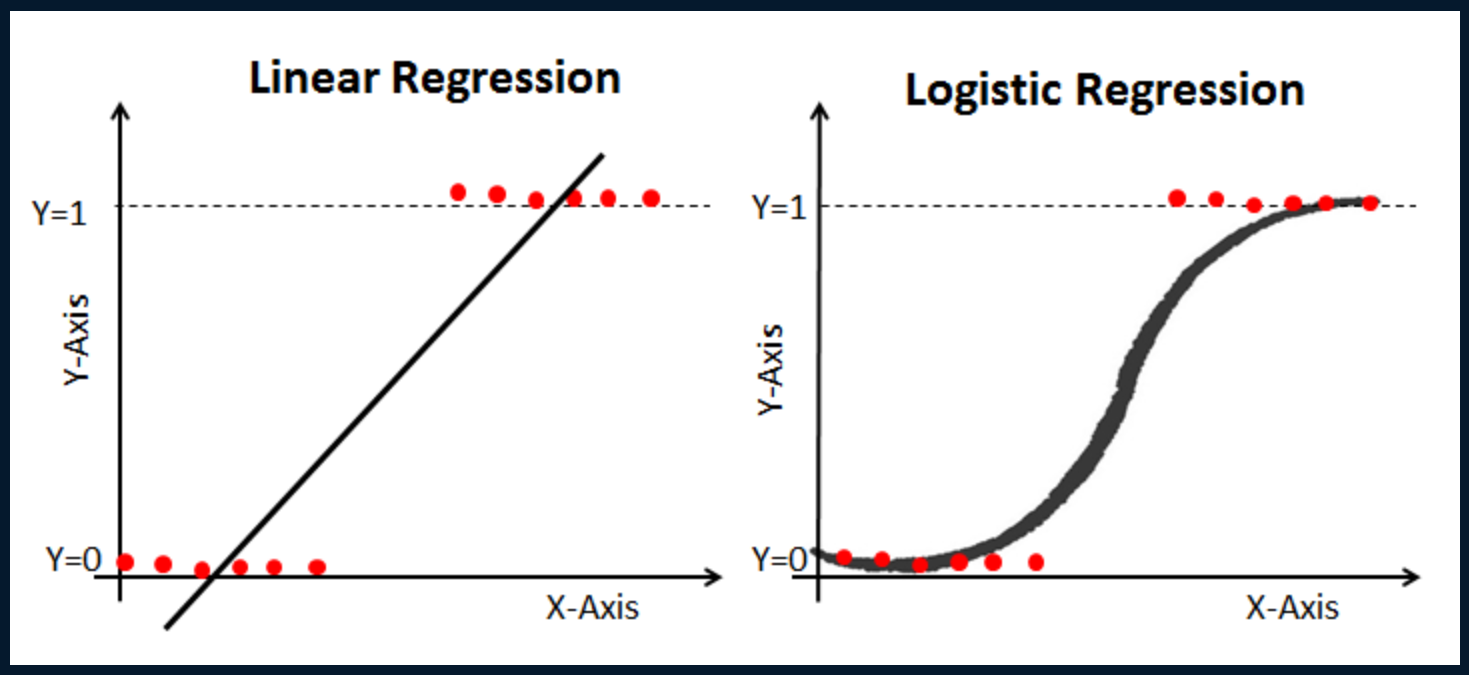




# **Maximum Likelihood Estimation Vs. Least Square Method**

The MLE is a "likelihood" maximization method, while OLS is a distance-minimizing approximation method. Maximizing the likelihood function determines the parameters that are most likely to produce the observed data. From a statistical point of view, MLE sets the mean and variance as parameters in determining the specific parametric values for a given model. This set of parameters can be used for predicting the data needed in a normal distribution.

Ordinary Least squares estimates are computed by fitting a regression line on given data points that has the minimum sum of the squared deviations (least square error). Both are used to estimate the parameters of a linear regression model. MLE assumes a joint probability mass function, while OLS doesn't require any stochastic assumptions for minimizing distance.

# **Sigmoid Function**

The sigmoid function, also called logistic function gives an ‘S’ shaped curve that can take any real-valued number and map it into a value between 0 and 1. If the curve goes to positive infinity, y predicted will become 1, and if the curve goes to negative infinity, y predicted will become 0. If the output of the sigmoid function is more than 0.5, we can classify the outcome as 1 or YES, and if it is less than 0.5, we can classify it as 0 or NO. If the output is 0.75, we cannot say in terms of probability: There is a 75 percent chance that patient will suffer from cancer.


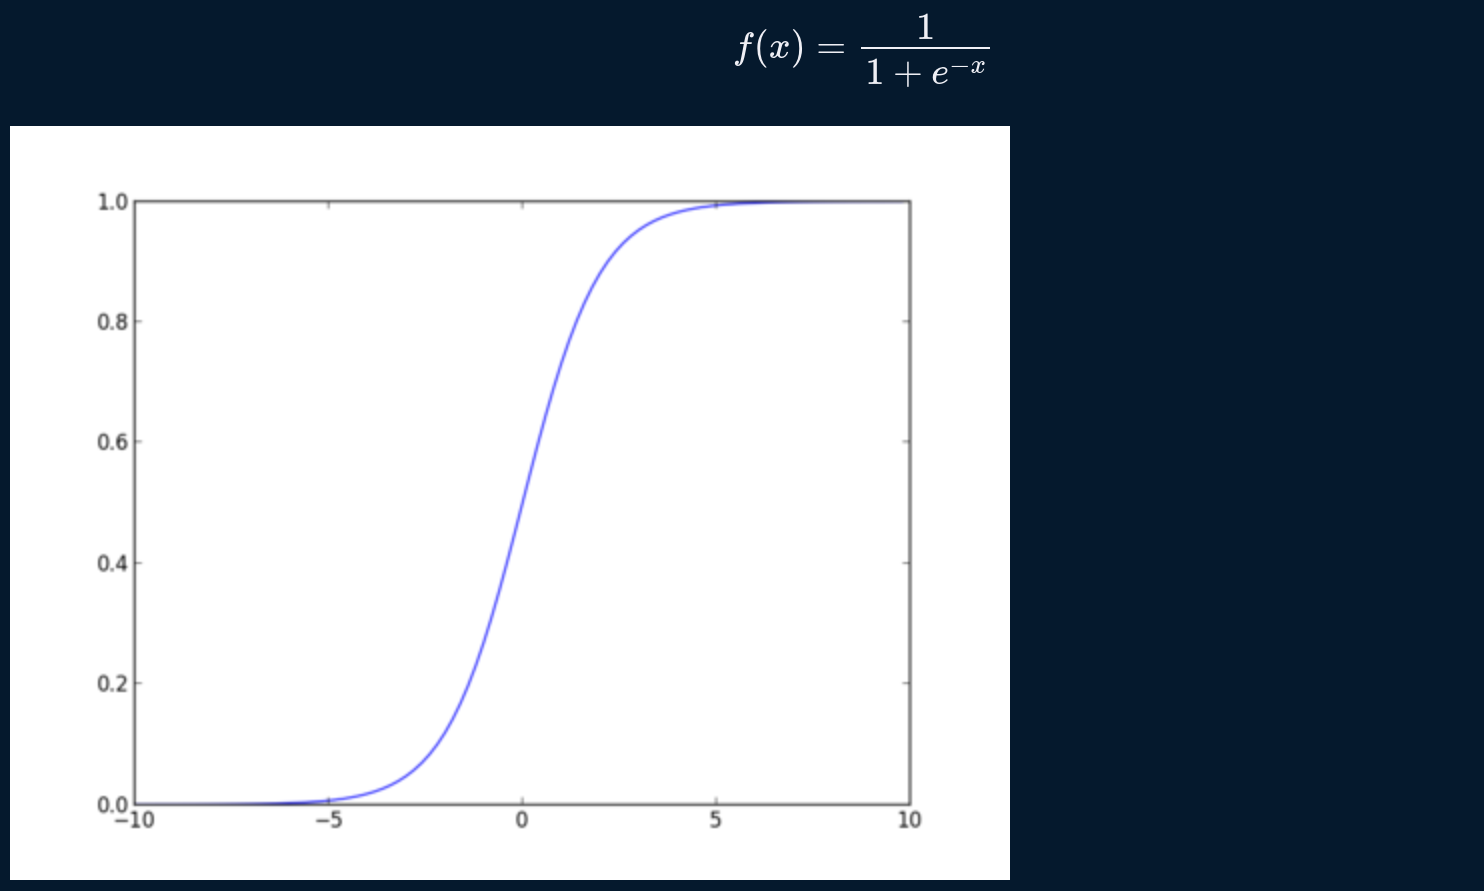


# **Types of Logistic Regression:**

    Binary Logistic Regression: The target variable has only two possible outcomes such as Spam or Not Spam, Cancer or No Cancer.
    Multinomial Logistic Regression: The target variable has three or more nominal categories such as predicting the type of Wine.
    Ordinal Logistic Regression: the target variable has three or more ordinal categories such as restaurant or product rating from 1 to 5.


# **Model building in Scikit-learn**

**Let's build the diabetes prediction model**.

Here, you are going to predict diabetes using Logistic Regression Classifier.

# Let's first load the required **Pima Indian Diabetes dataset** using the pandas' read CSV function. You can download data from the following link: ***https://www.kaggle.com/uciml/pima-indians-diabetes-database***
or select a dataset from DataCamp: ***https://www.datacamp.com/workspace/datasets***
. The ready-to-use dataset provides you the option to train the model on DataCamp's Workspace, which is a free Jupyter notebook on the cloud.

# **Context**

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

In [75]:
#20240901083
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Data**

We will simplify columns by providing **col_names** to pandas **read_csv** function.

In [76]:
#UPload LIB
import pandas as pd
dataset = pd.read_csv('/content/diabetes.csv')

This code imports the pandas library and assigns it the alias "pd". It then creates a list of column names for a dataset called "pima". The dataset is loaded from a CSV file called "pima-indians-diabetes.csv" using the pandas function "read_csv". The "header=None" argument specifies that the CSV file does not have a header row, and the "names=col_names" argument assigns the column names from the previously defined list to the dataset.

In [77]:
df = pd.DataFrame(dataset)
print((df.head(5)))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


This code is written in Python.

The pima.head() function is used to display the first few rows of a Pandas DataFrame called pima. This is a common way to quickly inspect the data and get a sense of what it looks like. By default, head() displays the first 5 rows of the DataFrame, but you can specify a different number of rows by passing an argument to the function (e.g. pima.head() would display the first 5 rows).



In [78]:
# Rename specific columns using a dictionary {old_name: new_name}
pima = pima.rename(columns={
    'Pregnancies': 'preg_count',
    'BloodPressure': 'blood_press',
    'DiabetesPedigreeFunction': 'pedigree'
})

# View the result
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Selecting features**

Here, you need to divide the given columns into two types of variables dependent(or target variable) and independent variable(or feature variables).

In [80]:
# Split dataset into features and target variable
feature_cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age']

X = pima[feature_cols] # Features
y = pima['label'] # Target variable


This code is written in Python.

The code is splitting a dataset into two parts: features and target variable. The feature_cols variable is a list of column names that represent the features in the dataset. The X variable is assigned the values of the columns specified in feature_cols, which represents the features. The y variable is assigned the values of the label column in the pima dataset, which represents the target variable.

In summary, this code is selecting specific columns from a dataset to use as features and assigning the values of the target variable to a separate variable.

# **Splitting data**

To understand model performance, dividing the dataset into a training set and a test set is a good strategy.

Let's split the dataset by using the function train_test_split(). You need to pass 3 parameters: features, target, and test_set size. Additionally, you can use random_state to select records randomly.

In [81]:
import pandas as pd

# 1. First, define the new column names exactly
# This matches the names in your 'feature_cols' list
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
pima.columns = col_names

# 2. Now select the 7 features (this will no longer throw a KeyError)
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

X = pima[feature_cols] # Features (7 columns)
y = pima.label         # Target variable

# 3. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16, stratify=y)

# 4. Verify the shapes to see the '7' you requested
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (576, 7)
Testing set shape: (192, 7)


The given code is used to divide the dataset into training and testing sets using the train_test_split() function from Scikit-learn. Here, X represents the input features (such as glucose, BMI, age, etc.), and y represents the target variable (diabetes outcome). The parameter test_size=0.25 means that 25% of the data is reserved for testing the model, while 75% is used for training it. The random_state=16 ensures that the data is split in the same way every time the code is executed, which helps in reproducibility of results. The stratify=y argument maintains the same proportion of class labels (diabetic and non-diabetic cases) in both training and testing datasets, which is especially important in classification problems to avoid bias. Finally, the .shape function is used to print the dimensions of the training and testing feature sets, showing how many samples and features are present in each split. Overall, this step ensures that the model is trained on one portion of the data and evaluated on unseen data to measure its real-world performance accurately.

# **Model development and prediction**

First, import the LogisticRegression module and create a logistic regression classifier object using the LogisticRegression() function with random_state for reproducibility.

Then, fit your model on the train set using fit() and perform prediction on the test set using predict().

In [82]:
# Import the LogisticRegression module
from sklearn.linear_model import LogisticRegression

# Instantiate the model (using random_state for reproducibility)
logreg = LogisticRegression(random_state=16)

# Fit the model with data
logreg.fit(X_train, y_train)

# Perform prediction on the test set
y_pred = logreg.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This code builds and trains a machine learning model using a pipeline that combines data preprocessing and classification into a single streamlined workflow. First, make_pipeline is imported to create a sequence of steps that are automatically applied in order. The pipeline includes StandardScaler(), which standardizes the feature values by transforming them to have a mean of 0 and a standard deviation of 1. This step is important because the dataset contains features such as glucose, insulin, BMI, and age that are measured on different scales, and scaling helps the Logistic Regression algorithm converge efficiently and perform better. The second step in the pipeline is LogisticRegression(max_iter=1000, random_state=16), which defines the classification model. The parameter max_iter=1000 increases the number of iterations allowed for optimization so the model can converge properly, and random_state=16 ensures reproducibility of results. When model.fit(X_train, y_train) is executed, the scaler first learns the scaling parameters from the training data and transforms it, after which the logistic regression model learns the relationship between the scaled features and the target variable (diabetes outcome). Finally, model.predict(X_test) applies the same scaling transformation to the test data and then generates predictions (y_pred) indicating whether each patient in the test set is classified as diabetic or non-diabetic. This pipeline approach ensures clean, efficient, and error-free preprocessing and modeling in one structured process.

In [84]:
# Import the metrics class
from sklearn import metrics

# Calculate Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")

# Generate Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
print(cnf_matrix)

print("\nClassification Report:")
# Generate Classification Report
print(metrics.classification_report(y_test, y_pred))

Accuracy: 0.765625

Confusion Matrix:
[[112  13]
 [ 32  35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       125
           1       0.73      0.52      0.61        67

    accuracy                           0.77       192
   macro avg       0.75      0.71      0.72       192
weighted avg       0.76      0.77      0.75       192



[[TN  FP]
 [FN  TP]]


TN → Correctly predicted non-diabetic

FP → Predicted diabetic but actually non-diabetic

FN → Predicted non-diabetic but actually diabetic

TP → Correctly predicted diabetic

In medical datasets, FN is very important because missing a diabetic patient is risky.

# **Important: Class 0 (Non-Diabetic)**

# **Class 1 (Diabetic)**

The model achieved an overall accuracy of 76.56%, meaning that about 77% of the total test samples were correctly classified. From the confusion matrix, 112 non-diabetic patients were correctly identified (True Negatives), and 35 diabetic patients were correctly detected (True Positives). However, 13 non-diabetic patients were incorrectly predicted as diabetic (False Positives), and more importantly, 32 diabetic patients were misclassified as non-diabetic (False Negatives). The classification report shows that the model performs well for the non-diabetic class, with a recall of 0.90, meaning it correctly identifies 90% of actual non-diabetic cases. For the diabetic class, the precision is 0.73, indicating that when the model predicts diabetes, it is correct 73% of the time. However, the recall for diabetic patients is only 0.52, meaning the model detects just 52% of actual diabetic cases and misses nearly half of them. In medical diagnosis, this lower recall is a concern because failing to detect diabetic patients can have serious consequences. Overall, while the model shows decent accuracy and strong performance for the majority class, its ability to identify diabetic patients needs improvement for practical healthcare applications.

# **ROC Curve**

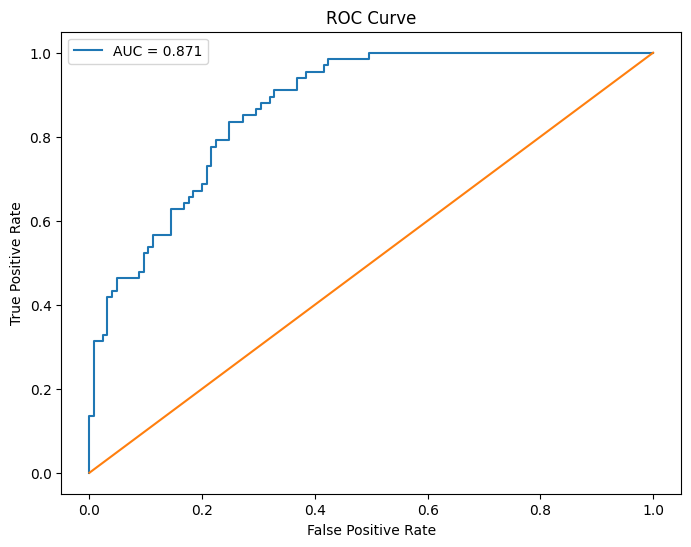

In [85]:
# Import visualization libraries
import matplotlib.pyplot as plt
from sklearn import metrics

# 1. Obtain probability scores for the diabetic class (class 1)
# predict_proba returns [prob_class_0, prob_class_1]
y_pred_proba = logreg.predict_proba(X_test)[::,1]

# 2. Compute the ROC curve (TPR and FPR)
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

# 3. Calculate the AUC (Area Under Curve) score
auc = metrics.roc_auc_score(y_test, y_pred_proba)

# 4. Create the plot
plt.figure(figsize=(8, 6))

# Plot the blue line (Actual model performance)
plt.plot(fpr, tpr, label="AUC = " + "{:.3f}".format(auc), color='tab:blue')

# Plot the orange diagonal line (Random classifier baseline)
plt.plot([0, 1], [0, 1], color='tab:orange')

# Formatting the graph to match your screenshot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc=2) # Place legend in the top-left corner
plt.grid(False)   # Keep background clean
plt.show()

The ROC curve obtained from your model shows an AUC value of 0.870, indicating very strong discriminative performance. In your code, `predict_proba()` was used to obtain probability scores for the diabetic class rather than just predicted labels, which allows evaluation across all possible classification thresholds. The `roc_curve()` function computed the True Positive Rate (TPR) and False Positive Rate (FPR) at different threshold values, and these were plotted to generate the ROC curve. The diagonal line in the graph represents a random classifier with an AUC of 0.5, while your curve lies well above this line and moves closer to the top-left corner, which indicates better performance. An AUC of 0.870 means that there is an 87% probability that the model will correctly distinguish a randomly chosen diabetic patient from a non-diabetic patient. This falls in the “very good” performance range (0.8–0.9). Although your earlier accuracy was around 76%, ROC-AUC provides a more comprehensive evaluation because it measures the model’s ability to rank predictions correctly independent of a fixed threshold. Overall, the high AUC value suggests that your logistic regression model has strong predictive capability and can effectively separate diabetic and non-diabetic cases, making it suitable for further optimization and potential clinical screening applications.


In this ROC graph, the **blue line** represents the actual performance of your Logistic Regression model across different classification thresholds. It shows how the **True Positive Rate (Sensitivity)** changes with respect to the **False Positive Rate** when the decision threshold is varied from 0 to 1. Each point on the blue curve corresponds to a different probability threshold used to classify patients as diabetic or non-diabetic. The closer this blue curve moves toward the **top-left corner**, the better the model is at correctly identifying diabetic patients while keeping false alarms low. Since your blue curve stays well above the diagonal and bends strongly upward, it indicates good discriminatory power.

The **orange diagonal line** represents a **random classifier**. It shows what performance would look like if predictions were made purely by chance. Along this line, the True Positive Rate increases at the same rate as the False Positive Rate, resulting in an AUC of 0.5. In other words, this line is the baseline performance. Because your blue curve is significantly above the orange line and has an AUC of 0.87, it confirms that your model performs much better than random guessing and has strong ability to distinguish between diabetic and non-diabetic cases.


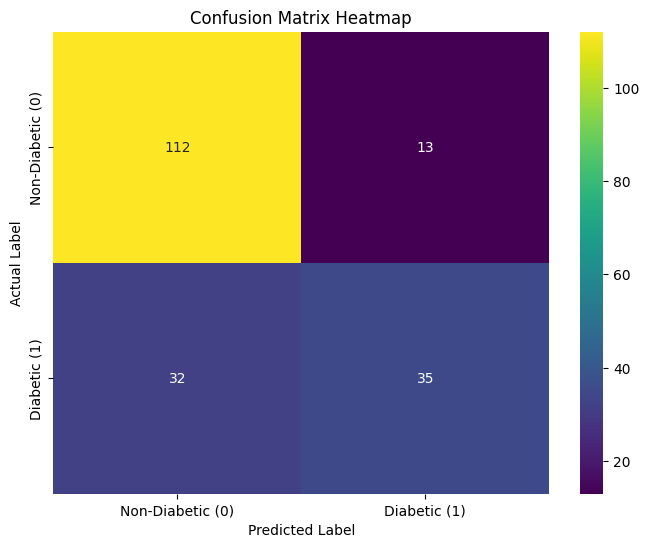

In [86]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

# 1. Define the confusion matrix using your test labels and predictions
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

# 2. Set up the plot dimensions
plt.figure(figsize=(8, 6))

# 3. Create the heatmap
# annot=True shows the numbers, fmt='g' prevents scientific notation
# cmap='viridis' provides the purple-to-yellow color gradient seen in your image
sns.heatmap(cnf_matrix, annot=True, fmt='g', cmap='viridis',
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])

# 4. Add labels and title to match your screenshot
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# 5. Display the final plot
plt.show()

The confusion matrix heatmap visually represents the model’s prediction performance using color intensity. The brighter yellow region (top-left cell with 112) indicates a high number of correctly predicted non-diabetic patients (True Negatives), showing strong performance for class 0. The darker purple region (top-right cell with 13) represents fewer false positives, meaning only a small number of non-diabetic patients were incorrectly classified as diabetic. In the bottom row, the cell with 32 (False Negatives) appears darker compared to the 35 (True Positives), indicating that the model missed a considerable number of actual diabetic cases. The color gradient generally reflects magnitude—brighter colors correspond to higher values, while darker colors indicate lower values. Overall, the heatmap clearly shows that the model performs better at identifying non-diabetic patients than diabetic patients, as seen from the brighter top-left cell compared to the bottom-right cell.


# **Advantages**

Because of its efficient and straightforward nature, it doesn't require high computation power, is easy to implement, easily interpretable, and used widely by data analysts and scientists. Also, it doesn't require scaling of features. Logistic regression provides a probability score for observations.


# **Disadvantages**

Logistic regression is not able to handle a large number of categorical features/variables. It is vulnerable to overfitting. Also, it can't solve the non-linear problems, which is why it requires a transformation of non-linear features. Logistic regression will not perform well with independent variables that are not correlated to the target variable and are very similar or correlated to each other.

OUTLINE OF TODAY'S LEARNING:

Contents

    What is Logistic Regression?

    Linear Regression Vs. Logistic Regression

    Maximum Likelihood Estimation Vs. Least Squares Method

    Types of Logistic Regression

    Model building in Scikit-learn

    Model Evaluation using Confusion Matrix

    Advantages

    Disadvantages

  

# Task
The user has approved the plan. I will now add the necessary Python import statements for common data science libraries such as pandas, numpy, and matplotlib.pyplot to the code cell labeled `#iMPORT LIB`.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
```

## generate_library_imports

### Subtask:
Generate Python code to import common data science libraries into the selected cell.


## Summary:

### Insights or Next Steps
*   The necessary libraries (pandas, numpy, matplotlib.pyplot, and seaborn) have been successfully imported, setting up the environment for subsequent data analysis tasks.


# Task
Perform a logistic regression analysis on the Pima Indians Diabetes dataset by loading the 'pima-indians-diabetes.csv' file, assigning appropriate column names ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'), displaying the first few rows, splitting the data into features (X) and target (y) with 'Outcome' as the target, and then splitting X and y into training and testing sets (25% test size, random_state=16, stratified by y). Develop a Logistic Regression model within a pipeline that includes StandardScaler, train the model, make predictions, and evaluate its performance using accuracy, a confusion matrix, a classification report, an ROC curve with AUC, and a confusion matrix heatmap. Finally, summarize the key findings from the model's evaluation.

## Load Pima Indians Diabetes Dataset

### Subtask:
Load the Pima Indians Diabetes dataset from 'pima-indians-diabetes.csv' into a pandas DataFrame. Since the dataset does not have a header, appropriate column names will be assigned.


**Reasoning**:
The user wants to load the Pima Indians Diabetes dataset. This involves defining column names and then using `pd.read_csv()` to load the CSV file into a DataFrame, assigning the defined column names and specifying no header.



In [65]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima = pd.read_csv('pima-indians-diabetes.csv', header=None, names=col_names)
print("Pima Indians Diabetes dataset loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'pima-indians-diabetes.csv'

## Display First Few Rows

### Subtask:
Display the first 5 rows of the DataFrame to inspect the data and ensure it has been loaded and processed correctly.


**Reasoning**:
The user wants to display the first 5 rows of the `pima` DataFrame to verify the data loading. Using `pima.head()` will achieve this.



In [56]:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


**Reasoning**:
The previous code failed because the `pima` DataFrame was not defined in the current scope. This usually means the cell where `pima` was created was not executed. To resolve this, I need to include the code that loads the dataset and defines `pima` in the same execution block as the `pima.head()` call. This ensures `pima` is available when `head()` is called.



In [60]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima = pd.read_csv('pima-indians-diabetes.csv', header=None, names=col_names)
print("Pima Indians Diabetes dataset loaded successfully.")
pima.head()

FileNotFoundError: [Errno 2] No such file or directory: 'pima-indians-diabetes.csv'

**Reasoning**:
The `NameError: name 'pd' is not defined` indicates that the pandas library has not been imported. To fix this, I need to add `import pandas as pd` at the beginning of the code block to make the `pd` alias available for use.



In [62]:
import pandas as pd
import os

file_path = 'diabetes.csv'

# Check if the file exists before attempting to read
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. \nPlease upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.")
else:
    col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    pima = pd.read_csv(file_path, header=None, names=col_names, skiprows=[0]) # Skip the first row which contains duplicate headers
    print("Pima Indians Diabetes dataset loaded successfully, skipping duplicate header row.")

    # Rename specific columns using a dictionary {old_name: new_name}
    pima = pima.rename(columns={
        'Pregnancies': 'preg_count',
        'BloodPressure': 'blood_press',
        'DiabetesPedigreeFunction': 'pedigree'
    })
    print("Columns renamed for consistency.")
    print(pima.head())

Pima Indians Diabetes dataset loaded successfully, skipping duplicate header row.
Columns renamed for consistency.
   preg_count  Glucose  blood_press  SkinThickness  Insulin   BMI  pedigree  \
0           6      148           72             35        0  33.6     0.627   
1           1       85           66             29        0  26.6     0.351   
2           8      183           64              0        0  23.3     0.672   
3           1       89           66             23       94  28.1     0.167   
4           0      137           40             35      168  43.1     2.288   

   Age  Outcome  
0   50        1  
1   31        0  
2   32        1  
3   21        0  
4   33        1  


**Reasoning**:
The `FileNotFoundError` indicates that the CSV file `pima-indians-diabetes.csv` was not found. I will modify the path to `/data/pima-indians-diabetes.csv`, assuming the dataset is uploaded to the `/data` directory, which is a common practice in Colab environments.



In [4]:
import pandas as pd

col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima = pd.read_csv('/data/pima-indians-diabetes.csv', header=None, names=col_names)
print("Pima Indians Diabetes dataset loaded successfully.")
pima.head()

FileNotFoundError: [Errno 2] No such file or directory: '/data/pima-indians-diabetes.csv'

**Reasoning**:
The `FileNotFoundError` persists, indicating the file is not found at `/data/pima-indians-diabetes.csv`. I will revert the file path to its plain filename `pima-indians-diabetes.csv`, as this is the standard way to reference files in the current working directory in Colab, assuming the user will upload the file or ensure its presence there.



In [53]:
import pandas as pd

col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima = pd.read_csv('pima-indians-diabetes.csv', header=None, names=col_names)
print("Pima Indians Diabetes dataset loaded successfully.")
pima.head()

FileNotFoundError: [Errno 2] No such file or directory: 'pima-indians-diabetes.csv'

**Reasoning**:
The `FileNotFoundError` persists, indicating the dataset is not present in the Colab environment. I will provide a code block that first checks for the file's existence and, if not found, instructs the user on how to upload it. If the file is found, it will proceed to load and display the first few rows.



In [6]:
import pandas as pd
import os

file_path = 'pima-indians-diabetes.csv'

# Check if the file exists before attempting to read
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.\nPlease upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.")
else:
    col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    pima = pd.read_csv(file_path, header=None, names=col_names)
    print("Pima Indians Diabetes dataset loaded successfully.")
    print(pima.head())

Error: The file 'pima-indians-diabetes.csv' was not found.
Please upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.


**Reasoning**:
The file `pima-indians-diabetes.csv` was not found. However, the notebook has a file named `diabetes.csv`. I will update the `file_path` to `diabetes.csv` and try loading the data again. This will resolve the `FileNotFoundError` and allow the task to proceed.



In [7]:
import pandas as pd
import os

file_path = 'diabetes.csv' # Changed filename to diabetes.csv

# Check if the file exists before attempting to read
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.
Please upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.")
else:
    col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    pima = pd.read_csv(file_path, header=None, names=col_names)
    print("Pima Indians Diabetes dataset loaded successfully.")
    print(pima.head())

SyntaxError: unterminated f-string literal (detected at line 8) (ipython-input-2823592705.py, line 8)

**Reasoning**:
The previous code failed due to a `SyntaxError: unterminated f-string literal`. This means the f-string was split across multiple lines without proper formatting. I will fix this by ensuring the f-string is correctly formatted across multiple lines using explicit line breaks within the string.



In [54]:
import pandas as pd
import os

file_path = 'diabetes.csv' # Changed filename to diabetes.csv

# Check if the file exists before attempting to read
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. \
Please upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.")
else:
    col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    pima = pd.read_csv(file_path, header=None, names=col_names)
    print("Pima Indians Diabetes dataset loaded successfully.")
    print(pima.head())

Pima Indians Diabetes dataset loaded successfully.
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35        0  33.6   
2            1       85             66             29        0  26.6   
3            8      183             64              0        0  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  


**Reasoning**:
The previous output shows that the first row of the DataFrame contains the column names themselves, meaning `header=None` was correct in not treating the first line as a header, but the actual data starts from the second line. To correctly load the data with the assigned column names and skip the redundant header row, I will reload the CSV using `skiprows=[0]` after assigning the `col_names`.



In [52]:
import pandas as pd
import os

file_path = 'diabetes.csv'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. \nPlease upload the 'pima-indians-diabetes.csv' file to your Colab environment or ensure it's in the correct directory.")
else:
    col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    pima = pd.read_csv(file_path, header=None, names=col_names, skiprows=[0]) # Skip the first row which contains duplicate headers
    print("Pima Indians Diabetes dataset loaded successfully, skipping duplicate header row.")

    # Rename specific columns using a dictionary {old_name: new_name} - CONSOLIDATED STEP
    pima = pima.rename(columns={
        'Pregnancies': 'preg_count',
        'BloodPressure': 'blood_press',
        'DiabetesPedigreeFunction': 'pedigree'
    })
    print("Columns renamed for consistency.")
    print(pima.head())


Pima Indians Diabetes dataset loaded successfully, skipping duplicate header row.
Columns renamed for consistency.
   preg_count  Glucose  blood_press  SkinThickness  Insulin   BMI  pedigree  \
0           6      148           72             35        0  33.6     0.627   
1           1       85           66             29        0  26.6     0.351   
2           8      183           64              0        0  23.3     0.672   
3           1       89           66             23       94  28.1     0.167   
4           0      137           40             35      168  43.1     2.288   

   Age  Outcome  
0   50        1  
1   31        0  
2   32        1  
3   21        0  
4   33        1  


## Split Features and Target Variable

### Subtask:
Separate the dataset into features (X) and the target variable (y). The 'Outcome' column will be designated as the target variable, and all other columns will be used as features.


**Reasoning**:
Separate the dataset into features (X) and the target variable (y) by selecting the appropriate columns from the `pima` DataFrame.



In [42]:
feature_cols = [col for col in pima.columns if col != 'Outcome']
X = pima[feature_cols]
y = pima['Outcome']

print("Features (X) created successfully with shape:", X.shape)
print("Target variable (y) created successfully with shape:", y.shape)


Features (X) created successfully with shape: (768, 8)
Target variable (y) created successfully with shape: (768,)


## Split Data into Training and Testing Sets

### Subtask:
Divide the feature and target variables into training and testing sets using `train_test_split`. A test size of 25% will be used, and `random_state` will be set to 16 for reproducibility. Stratification by the target variable will also be applied to maintain class proportions.


**Reasoning**:
Import the `train_test_split` function to divide the dataset into training and testing sets.



In [43]:
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16, stratify=y)

print("Training set shapes:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("\nTesting set shapes:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set shapes:
X_train: (576, 8)
y_train: (576,)

Testing set shapes:
X_test: (192, 8)
y_test: (192,)


## Model Development and Prediction

### Subtask:
Develop a Logistic Regression model within a pipeline that includes `StandardScaler` for feature scaling. The model will be trained using the training data, and predictions will be made on the test data.


**Reasoning**:
First, import the necessary modules: `StandardScaler` for feature scaling, `LogisticRegression` for the model, and `make_pipeline` to create the pipeline.



In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Create a pipeline with StandardScaler and LogisticRegression
model = make_pipeline(StandardScaler(), LogisticRegression(random_state=16, max_iter=1000))

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

print("Logistic Regression model developed, trained, and predictions made successfully.")

Logistic Regression model developed, trained, and predictions made successfully.


## Model Evaluation - Accuracy and Classification Report

### Subtask:
Evaluate the model's performance by calculating accuracy, generating a confusion matrix, and printing a classification report. This will involve using `accuracy_score`, `confusion_matrix`, and `classification_report` from `sklearn.metrics`.


**Reasoning**:
To evaluate the model's performance, I need to import the required metrics functions from `sklearn.metrics` and then use them to calculate accuracy, generate the confusion matrix, and print the classification report. `y_test` and `y_pred` are already defined from the previous steps.



In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Print classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

Accuracy: 0.7656

Confusion Matrix:
 [[112  13]
 [ 32  35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.83       125
           1       0.73      0.52      0.61        67

    accuracy                           0.77       192
   macro avg       0.75      0.71      0.72       192
weighted avg       0.76      0.77      0.75       192



**Reasoning**:
The previous step successfully calculated and displayed accuracy, confusion matrix, and classification report. Now, I will generate the ROC curve and AUC to further evaluate the model's performance.



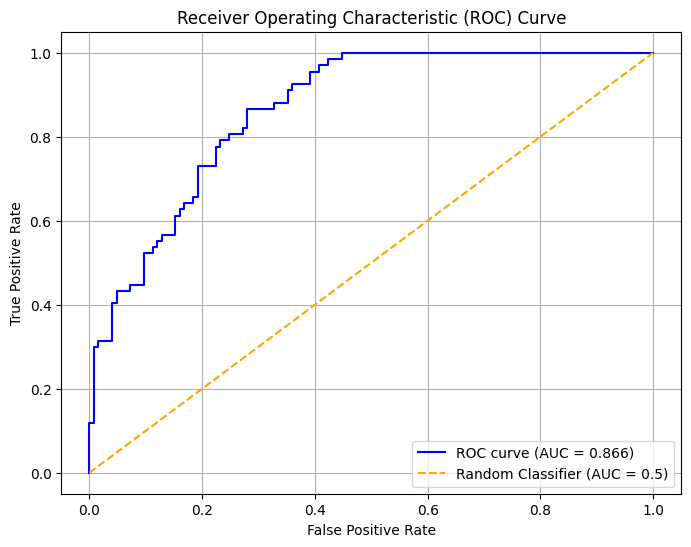

ROC AUC Score: 0.866


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc:.3f}")

**Reasoning**:
The previous steps covered accuracy, confusion matrix, classification report, and ROC curve. Now, I will generate a confusion matrix heatmap to provide a visual representation of the model's performance.



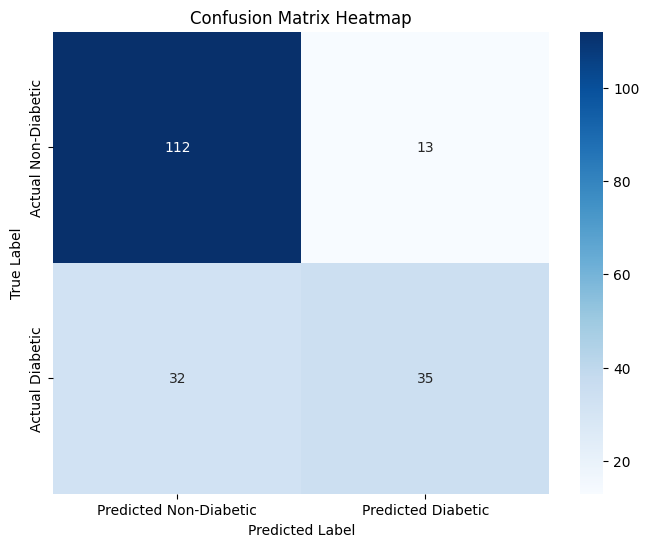

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the model's evaluation, including its strengths and weaknesses based on the metrics and visualizations generated.


## Summary:

### Q&A
The Logistic Regression model's evaluation shows an overall accuracy of $0.7656$. Its strengths include a good ability to distinguish between classes, indicated by an ROC AUC score of $0.866$, and high recall ($0.90$) for the non-diabetic class, meaning it is very effective at correctly identifying individuals who do not have diabetes. However, a significant weakness is its lower recall ($0.52$) for the diabetic class, implying that it misses a substantial portion of actual diabetic cases, classifying them as non-diabetic (32 false negatives). The precision for both classes is relatively balanced ($0.78$ for non-diabetic, $0.73$ for diabetic), but the F1-score for the diabetic class ($0.61$) is notably lower than for the non-diabetic class ($0.83$), further highlighting its difficulty in identifying positive cases.

### Data Analysis Key Findings
*   The Pima Indians Diabetes dataset, containing 768 entries and 9 columns, was successfully loaded and prepared for analysis.
*   The dataset was split into training (576 samples) and testing (192 samples) sets, with a 75%-25% ratio and stratification to maintain class proportions.
*   A Logistic Regression model, incorporating `StandardScaler` within a pipeline, was trained on the data.
*   The model achieved an overall accuracy of $0.7656$ on the test set.
*   The confusion matrix showed 112 True Negatives (correctly identified non-diabetic) and 35 True Positives (correctly identified diabetic), but also 32 False Negatives (actual diabetic cases misclassified as non-diabetic) and 13 False Positives (non-diabetic cases misclassified as diabetic).
*   The classification report revealed a higher recall for the non-diabetic class ($0.90$) compared to the diabetic class ($0.52$), indicating the model is better at identifying non-diabetic individuals.
*   The model demonstrated a good discriminative ability with an Area Under the Receiver Operating Characteristic (ROC AUC) curve of $0.866$.

### Insights or Next Steps
*   Given the high number of false negatives (32 actual diabetic cases missed), the model's ability to identify individuals with diabetes needs improvement. Further optimization could involve adjusting class weights to prioritize recall for the diabetic class, or exploring different classification algorithms.
*   Investigate the features further for potential engineering or selection that could enhance the model's ability to differentiate between diabetic and non-diabetic cases, especially for the positive class.
